In [101]:
import numpy as np
import pandas as pd
#Import required libraries numpy for calculations and pandas for data manupulation.

In [102]:
df=pd.read_csv('/content/customer.csv')
#Uploading the dataset.

In [103]:
df
#Our dataset look like this

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [104]:
df.info()
#Use info function to have a look at columns in our dataset.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [105]:
#To gain insights into the dataset we first check for missing values and understand its structure. The dataset includes features such as:
df.isnull().sum()


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [106]:
#Check the statistical information of dataset.
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [107]:
#Check the number of churners and non-churners to understand the balance of the dataset using seaborn and matplotlib libraries.
import seaborn as sns
import matplotlib.pyplot as plt

Churn
No     5174
Yes    1869
Name: count, dtype: int64


/tmp/ipykernel_20164/1228532273.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn',data=df,palette='coolwarm')


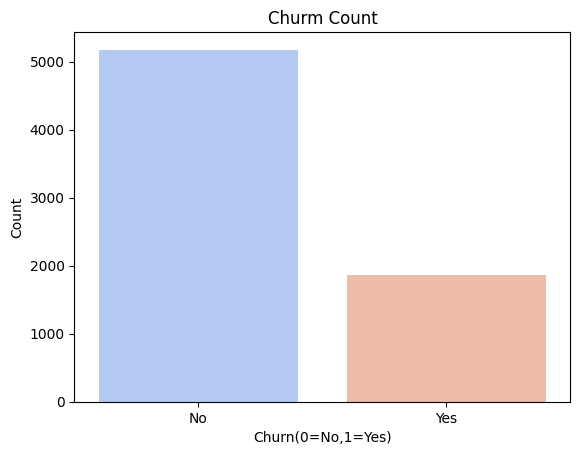

In [108]:
sns.countplot(x='Churn',data=df,palette='coolwarm')
print(df['Churn'].value_counts())
plt.title('Churm Count')
plt.xlabel('Churn(0=No,1=Yes)')
plt.ylabel('Count')
plt.show()

In [109]:
#Check the total numbers of Yes and No of churns.
df.value_counts('Churn')

,count
Churn,
No,5174
Yes,1869


In [110]:
#Converts the TotalCharges column to numerical format. If any value is not convertible (e.g., empty spaces), it replaces it with NaN.
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')

In [111]:
#Replaces missing values (NaN) with the median of the column to maintain consistency in numerical values.
df['TotalCharges'].fillna(df['TotalCharges'].median(),inplace=True)

/tmp/ipykernel_20164/3639909367.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(),inplace=True)


In [112]:
#Drop the customer id column which is irrelevant for prediction.
df.drop(['customerID'],axis=1,inplace=True)

In [113]:
#Handling Categorical Variables
#Some features like State, International Plan and Voice Mail Plan are categorical and must be converted into numerical values for model training.LabelEncoder() converts categorical values into numerical form. Each unique category is assigned a numeric label.

from sklearn.preprocessing import LabelEncoder

In [116]:
#
le=LabelEncoder()

In [115]:
#The loop iterates through each categorical column and applies fit_transform() to encode categorical variables into numbers.
columns=['gender','Partner','Dependents','PhoneService','MultipleLines','InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','Contract','PaperlessBilling','PaymentMethod']
for col in columns:
  df[col]=le.fit_transform(df[col])

In [114]:
#Importing the train test split model to split the dataset into training and testing.
from sklearn.model_selection import train_test_split

In [117]:
#Using iloc function to sepatate the features column  from the dataset and store it in x variable.
x=df.iloc[:,0:17]
x


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,2,0,2,0,2,2,2,2,1,1,3
7039,0,0,1,1,72,1,2,1,0,2,2,0,2,2,1,1,1
7040,0,0,1,1,11,0,1,0,2,0,0,0,0,0,0,1,2
7041,1,1,1,0,4,1,2,1,0,0,0,0,0,0,0,1,3


In [118]:
#Using iloc function to sepatate the target column  from the dataset and store it in y variable.
y=df['Churn']
y

,Churn
0,No
1,No
2,Yes
3,No
4,Yes
...,...
7038,No
7039,No
7040,No
7041,Yes


In [119]:
#Now split the dataset in train and test form and take the 20% of the data for training purpose of the model and taking random state=1
x_test,x_train,y_test,y_train=train_test_split(x,y,test_size=0.20,random_state=1)

#Since features are on different scales we apply standardization to improve model performance. It prevents models from being biased toward larger numerical values and improves convergence speed in optimization algorithms like gradient descent

In [121]:
#Standardizes data by transforming it to have a mean of 0 and a standard deviation of 1 ensuring all features are on a similar scale.

from sklearn.preprocessing import StandardScaler

In [122]:
#Storing the StandardScaler function in std variable.
std=StandardScaler()

In [123]:
#Fits the scaler to the training data and transforms it.
X_train=std.fit_transform(x_train)
X_test=std.fit_transform(x_test)

In [124]:
#For training our model we use Random Forest Classifier. It is an ensemble learning method that combines the results of multiple decision trees to make a final prediction.
from sklearn.ensemble import RandomForestClassifier
rfc=RandomForestClassifier()

In [128]:
rfc.fit(X_train,y_train)

RandomForestClassifier()

In [129]:
#To measure model performance we calculate accuracy using the accuracy_score function.
from sklearn.metrics import accuracy_score

In [130]:
y_pred=rfc.predict(X_test)

In [96]:
accuracy=accuracy_score(y_test,y_pred)

In [97]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")

Model Accuracy: 0.79


In [131]:
#We evaluate precision, recall and accuracy using a confusion matrix.
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

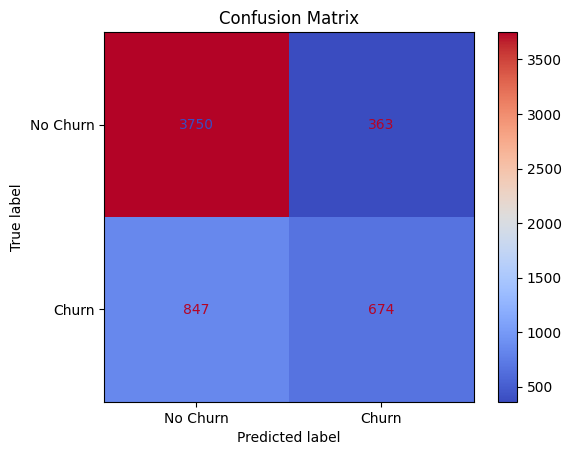

In [99]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Churn", "Churn"])
disp.plot(cmap="coolwarm")
plt.title('Confusion Matrix')
plt.show()

#
Confusion matrix shows how well the model predicts customer churn. It correctly identifies 3750 non-churners and 674 churners. However 363 non-churners are wrongly classified as churners and 847 churners are missed. The high number of missed churners suggests the model may need further tuning.